Importing data from file

#importing data
import pandas as p

In [ ]:
window_size = 4
words = []
import re
with open('linux_data.txt', 'r', encoding='utf-8') as f:
    text = f.read()
# remove /* ... */ comments (multi-line)
text = re.sub(r'/\*.*?\*/', '', text, flags=re.DOTALL)

# remove // ... comments (single-line)
text = re.sub(r'//.*', '', text)

# remove blank lines left after removing comments
text = '\n'.join(line for line in text.splitlines() if line.strip())
# Split into lines
lines = text.split('\n')

for line in lines:
    line = line.strip()
    if not line:
        continue
    parts = line.split() 

    words.extend(parts + ['<PAD>'] * window_size)

print(words[:50])


['#include', '<linux/irq.h>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '#include', '<linux/module.h>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '#include', '<linux/interrupt.h>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '#include', '<linux/delay.h>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '#include', '<linux/async.h>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '#include', '"internals.h"', '<PAD>', '<PAD>', '<PAD>', '<PAD>', 'static', 'DEFINE_MUTEX(probing_active);', '<PAD>', '<PAD>', '<PAD>', '<PAD>', 'unsigned', 'long', 'probe_irq_on(void)', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '{']


In [4]:
# import re

# # Read the dataset
# with open('linux_data.txt', 'r', encoding='utf-8') as f:
#     text = f.read()

# text = text.split('\n')


In [5]:
# window_size = 4

# words = []
# for line in text:
#     line = line.strip()
#     if line:  # skip empty lines
#         words.extend(line.split(' ') + ['<PAD>'] * window_size)

In [6]:
words

['#include',
 '<linux/irq.h>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '#include',
 '<linux/module.h>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '#include',
 '<linux/interrupt.h>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '#include',
 '<linux/delay.h>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '#include',
 '<linux/async.h>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '#include',
 '"internals.h"',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 'static',
 'DEFINE_MUTEX(probing_active);',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 'unsigned',
 'long',
 'probe_irq_on(void)',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '{',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 'struct',
 'irq_desc',
 '*desc;',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 'unsigned',
 'long',
 'mask',
 '=',
 '0;',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 'int',
 'i;',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 'async_synchronize_full();',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 '<PAD>',
 'mutex_lock(&probing_active);',
 '<PAD>',
 '<PAD>',
 '<PAD>'

In [7]:
window_size = 4

X, Y = [], []
for i in range(len(words)):
    start_idx = max(0, i - window_size)
    context = words[start_idx:i]
    context = ['<PAD>'] * (window_size - len(context)) + context  # left padding
    target = words[i]
    
    X.append(context)
    Y.append(target)


for i in range(100):
    print(' '.join(X[i]), '--->', Y[i])


<PAD> <PAD> <PAD> <PAD> ---> #include
<PAD> <PAD> <PAD> #include ---> <linux/irq.h>
<PAD> <PAD> #include <linux/irq.h> ---> <PAD>
<PAD> #include <linux/irq.h> <PAD> ---> <PAD>
#include <linux/irq.h> <PAD> <PAD> ---> <PAD>
<linux/irq.h> <PAD> <PAD> <PAD> ---> <PAD>
<PAD> <PAD> <PAD> <PAD> ---> #include
<PAD> <PAD> <PAD> #include ---> <linux/module.h>
<PAD> <PAD> #include <linux/module.h> ---> <PAD>
<PAD> #include <linux/module.h> <PAD> ---> <PAD>
#include <linux/module.h> <PAD> <PAD> ---> <PAD>
<linux/module.h> <PAD> <PAD> <PAD> ---> <PAD>
<PAD> <PAD> <PAD> <PAD> ---> #include
<PAD> <PAD> <PAD> #include ---> <linux/interrupt.h>
<PAD> <PAD> #include <linux/interrupt.h> ---> <PAD>
<PAD> #include <linux/interrupt.h> <PAD> ---> <PAD>
#include <linux/interrupt.h> <PAD> <PAD> ---> <PAD>
<linux/interrupt.h> <PAD> <PAD> <PAD> ---> <PAD>
<PAD> <PAD> <PAD> <PAD> ---> #include
<PAD> <PAD> <PAD> #include ---> <linux/delay.h>
<PAD> <PAD> #include <linux/delay.h> ---> <PAD>
<PAD> #include <linux/dela

In [8]:
from collections import Counter

word_counts = Counter(words)
vocab = sorted(word_counts.keys()) 
vocab_size = len(vocab)

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 98


In [9]:
most_common_10 = word_counts.most_common(10)
least_common_10 = word_counts.most_common()[-10:]

print("10 Most Frequent Words:", most_common_10)
print("10 Least Frequent Words:", least_common_10)


10 Most Frequent Words: [('<PAD>', 420), ('#include', 18), ('{', 15), ('}', 15), ('if', 13), ('&', 7), ('=', 6), ('int', 6), ('mask', 5), ('i;', 5)]
10 Least Frequent Words: [('<linux/init.h>', 1), ('<linux/spinlock.h>', 1), ('<linux/smp.h>', 1), ('<linux/sched.h>', 1), ('<linux/atomic.h>', 1), ('<linux/bitops.h>', 1), ('<linux/percpu.h>', 1), ('<linux/notifier.h>', 1), ('<linux/cpu.h>', 1), ('#inclu', 1)]


In [10]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using NVIDIA GPU (CUDA)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using Apple Silicon GPU (MPS)


In [11]:
stoi = {word: i for i, word in enumerate(vocab)}
itos = {i: word for word, i in stoi.items()}
emb_dim = 64
emb = torch.nn.Embedding(len(stoi), emb_dim)
print(stoi)
print(itos)

{'!(desc->istate': 0, '"internals.h"': 1, '#inclu': 2, '#include': 3, '&': 4, '&&': 5, '&=': 6, '(!(desc->istate': 7, '(!desc->action': 8, '(!nr_of_irqs)': 9, '(desc->irq_data.chip->irq_set_type)': 10, '(desc->istate': 11, '(i': 12, '(irq_startup(desc,': 13, '(nr_of_irqs': 14, '*desc;': 15, '-irq_found;': 16, '0,': 17, '0;': 18, '1': 19, '1)': 20, '16': 21, '32)': 22, '<': 23, '<<': 24, '<PAD>': 25, '<linux/async.h>': 26, '<linux/atomic.h>': 27, '<linux/bitops.h>': 28, '<linux/cpu.h>': 29, '<linux/delay.h>': 30, '<linux/init.h>': 31, '<linux/interrupt.h>': 32, '<linux/irq.h>': 33, '<linux/kernel.h>': 34, '<linux/module.h>': 35, '<linux/notifier.h>': 36, '<linux/percpu.h>': 37, '<linux/sched.h>': 38, '<linux/smp.h>': 39, '<linux/spinlock.h>': 40, '<linux/types.h>': 41, '=': 42, '>': 43, 'DEFINE_MUTEX(probing_active);': 44, 'EXPORT_SYMBOL(probe_irq_mask);': 45, 'EXPORT_SYMBOL(probe_irq_off);': 46, 'EXPORT_SYMBOL(probe_irq_on);': 47, 'IRQS_AUTODETECT': 48, 'IRQS_AUTODETECT)': 49, 'IRQS_PE

In [12]:
print(emb.weight.shape)  # should be (vocab_size, emb_dim)

torch.Size([98, 64])


In [13]:
X_encoded = [[stoi[word] for word in seq] for seq in X]
Y_encoded = [stoi[word] for word in Y] 

In [14]:
print(X_encoded[:5])

[[25, 25, 25, 25], [25, 25, 25, 3], [25, 25, 3, 33], [25, 3, 33, 25], [3, 33, 25, 25]]


In [15]:
stoi['<PAD>']

25

In [16]:
X = torch.tensor(X_encoded, dtype=torch.long).to(device)
Y = torch.tensor(Y_encoded, dtype=torch.long).to(device)

In [17]:
emb.weight

Parameter containing:
tensor([[-0.0042,  0.6876,  0.1871,  ..., -0.8708, -0.6763,  0.3615],
        [ 1.1743,  1.2069, -0.9098,  ..., -0.3506,  0.6916, -0.2418],
        [ 0.6532, -1.1187, -0.3922,  ...,  0.4886,  0.3025,  0.1403],
        ...,
        [ 0.5289,  1.0026, -1.6158,  ...,  0.0080, -0.5122, -2.2037],
        [-0.7284, -0.1223, -0.2191,  ..., -0.3089, -0.4895,  0.7253],
        [-1.6280, -1.2102, -2.3681,  ..., -1.4374,  1.2386, -0.1823]],
       requires_grad=True)

In [18]:
emb.weight.shape

torch.Size([98, 64])

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [20]:
class Nextword(nn.Module):
    def __init__(self, block_size, vocab_size, emb_dim=64, hidden_size=1024):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.fc1 = nn.Linear(block_size * emb_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # x: (batch, block_size)
        x = self.emb(x)                           # (batch, block_size, emb_dim)
        x = x.view(x.shape[0], -1)                # flatten
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        x = self.fc3(x)                           # logits
        return x



In [21]:
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
train_data = torch.utils.data.TensorDataset(X_train, Y_train)
val_data = torch.utils.data.TensorDataset(X_val, Y_val)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32)



In [22]:
import time
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_model_summary(model):
    print("Model Summary:")
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:
            params = sum(p.numel() for p in module.parameters())
            print(f"{name:<20} {params:,} parameters")
    print(f"\nTotal trainable parameters: {count_params(model):,}\n")


import torch
import torch.nn as nn
import time

def train_model(model, X, Y, X_val, Y_val, epochs=500, batch_size=1024, lr=1e-3, wd=1e-4, print_every=100):
    """Train the MLP model using AdamW optimizer."""
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()

    losses, times, val_losses = [], [], []

    for epoch in range(epochs):
        start = time.time()
        total_loss, n_batches = 0, 0

        # -------- Training --------
        for i in range(0, X.shape[0], batch_size):
            x_batch = X[i:i+batch_size]
            y_batch = Y[i:i+batch_size]

            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / n_batches
        losses.append(avg_loss)
        times.append(time.time() - start)

        # -------- Validation --------
        model.eval()
        val_total_loss, val_batches = 0, 0
        with torch.no_grad():
            for i in range(0, X_val.shape[0], batch_size):
                x_batch = X_val[i:i+batch_size]
                y_batch = Y_val[i:i+batch_size]

                logits = model(x_batch)
                loss = loss_fn(logits, y_batch)
                val_total_loss += loss.item()
                val_batches += 1

        avg_val_loss = val_total_loss / val_batches
        val_losses.append(avg_val_loss)
        model.train()

        # -------- Logging --------
        if epoch % print_every == 0:
            print(f"Epoch {epoch:4d} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {times[-1]:.2f}s")

    return losses, times, val_losses


In [23]:
# Create enhanced model and show before training
block_size = 4
model = Nextword(block_size, len(stoi), emb_dim).to(device)
model = torch.compile(model)

## Model parameters:
print_model_summary(model)


Model Summary:
_orig_mod.emb        6,272 parameters
_orig_mod.fc1        263,168 parameters
_orig_mod.fc2        1,049,600 parameters
_orig_mod.fc3        100,450 parameters

Total trainable parameters: 1,419,490



In [41]:
import torch

def generate_text(model, stoi, itos, block_size, device, start_context=None, max_len=20):
    """
    Generate a sequence of words from a trained model.

    Args:
        model: Trained PyTorch language model
        stoi: dict, mapping from word → index
        itos: dict, mapping from index → word
        block_size: int, context size expected by the model
        device: torch device ('cuda' or 'cpu')
        start_context: list of str (optional), seed words
        max_len: int, number of words to generate

    Returns:
        str: Generated text sequence
    """

    model.eval()  # evaluation mode (no dropout, etc.)

    # --- Initialize context ---
    if start_context is None:
        context = [stoi['<PAD>']] * block_size  # start with padding
    else:
        # convert words → indices, pad or truncate to block_size
        context = [stoi.get(w, 0) for w in start_context][-block_size:]
        context = [stoi['<PAD>']] * (block_size - len(context)) + context

    generated_words = []

    # --- Generate words one by one ---
    with torch.no_grad():
        for _ in range(max_len):
            x = torch.tensor(context).view(1, -1).to(device)
            y_pred = model(x)  # logits for next word
            ix = torch.distributions.categorical.Categorical(logits=y_pred).sample().item()
            word = itos[ix]

            # stop at end token 
            # if word == eos:
            #     break

            generated_words.append(word)

            # slide the context window forward
            context = context[1:] + [ix]

    model.train()  # restore training mode
    i = 0
    new_words = []
    while i < len(generated_words):
        # If 3 or more <PAD> in a row
        if i + 2 < len(generated_words) and generated_words[i:i+3] == ['<PAD>', '<PAD>', '<PAD>']:
            # Skip all consecutive <PAD>
            while i < len(generated_words) and generated_words[i] == '<PAD>':
                i += 1
            new_words.append('\n')
        else:
            if generated_words[i] != '<PAD>':
                new_words.append(generated_words[i])
            i += 1
    return ' '.join(new_words)


    return ' '.join(generated_words)


In [25]:
text = generate_text(model, stoi, itos, block_size=4, device=device)
print(text)

W1103 18:59:12.004000 20226 torch/_inductor/utils.py:1436] [0/0] Not enough SMs to use max_autotune_gemm mode


<linux/atomic.h> <linux/async.h> (nr_of_irqs > | i; static & <linux/smp.h> (irq_startup(desc, IRQS_WAITING; (!nr_of_irqs) (i (desc->istate IRQS_WAITING)) EXPORT_SYMBOL(probe_irq_on); irq_settings_can_probe(desc)) irq_found unsigned desc->irq_data.chip->irq_set_type(&desc->irq_data,


In [38]:
losses, timing , val_losses = train_model(model, X_train, Y_train,X_val,Y_val, epochs=500, batch_size=4096 , lr=1e-3, wd=1e-3, print_every=100)

Epoch    0 | Train Loss: 0.5572 | Val Loss: 4.2001 | Time: 0.07s
Epoch  100 | Train Loss: 0.5572 | Val Loss: 4.5006 | Time: 0.01s
Epoch  200 | Train Loss: 0.5572 | Val Loss: 4.5684 | Time: 0.01s
Epoch  300 | Train Loss: 0.5572 | Val Loss: 4.6011 | Time: 0.01s
Epoch  400 | Train Loss: 0.5572 | Val Loss: 4.6149 | Time: 0.01s


In [42]:
text = generate_text(model, stoi, itos, block_size=4, device=device, max_len=50)
print(text)

if (i < 32) < 32) <linux/percpu.h> 
 for_each_irq_desc(i, desc) { 
 raw_spin_lock_irq(&desc->lock); 
 raw_spin_lock_irq(&desc->lock); 
 if (irq_startup(desc, false)) 
 } 
 mask |= 1 << i; 
 return


In [28]:
import pandas as pd
df = pd.DataFrame({
    'Epoch': range(1, len(losses) + 1),
    'Train_Loss': losses,
    'Val_Loss': val_losses,
    'Timing': timing
})
df.to_csv('training_log_part_b.csv', index=False)



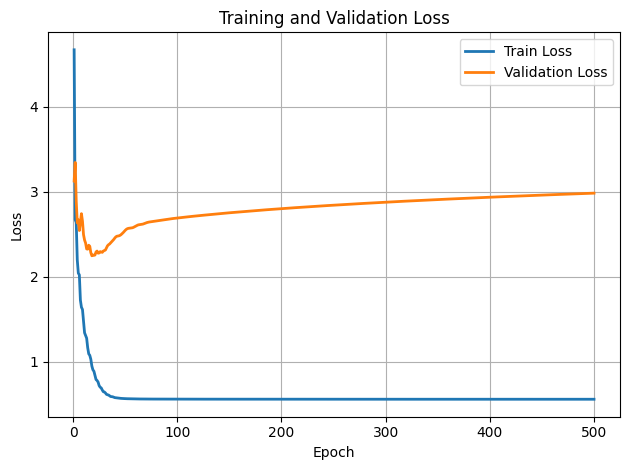

In [29]:
import matplotlib.pyplot as plt

plt.plot(df['Epoch'], df['Train_Loss'], label='Train Loss', linewidth=2)
plt.plot(df['Epoch'], df['Val_Loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

In [30]:
criterion = nn.CrossEntropyLoss()
val_loss = 0.0

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

val_loss /= len(val_loader)
accuracy = correct / total

print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {accuracy * 100:.2f}%')


Validation Loss: 2.9682
Validation Accuracy: 62.41%


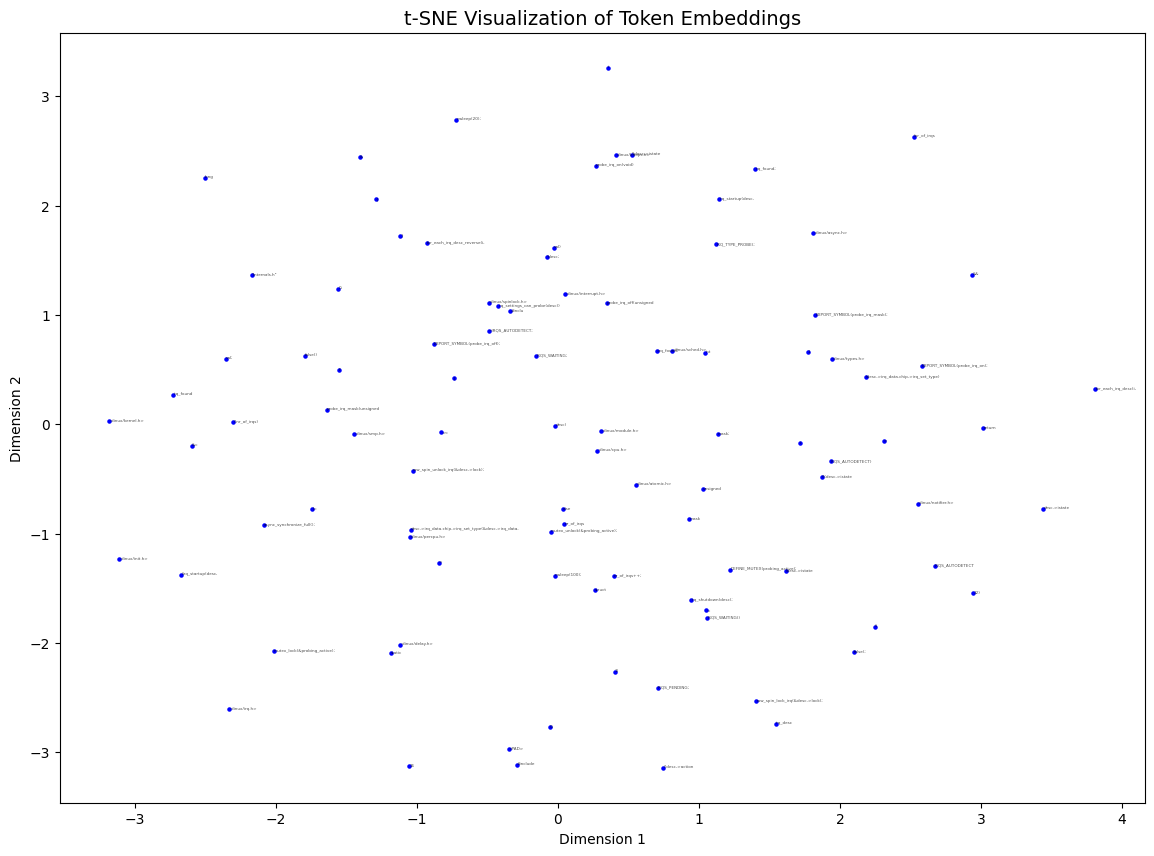

In [31]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Extract embeddings from wrapped model
embedding_matrix = model._orig_mod.emb.weight.detach().cpu().numpy()

# Use max_iter instead of n_iter for sklearn >= 1.6
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embedding_2d = tsne.fit_transform(embedding_matrix)

# Plot
plt.figure(figsize=(14, 10))
for i, token_id in enumerate(itos):
    x, y = embedding_2d[i, 0], embedding_2d[i, 1]
    plt.scatter(x, y, color='blue', s=5)  # Reduce marker size to s=10
    plt.text(x, y, itos[token_id], fontsize=3, alpha=0.7)  # Smaller text and transparency

plt.title("t-SNE Visualization of Token Embeddings", fontsize=14)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


In [32]:
torch.save(model.state_dict(), 'nextword-model-lightning_part_b.pth')

In [33]:
from google.colab import drive
drive.mount('/content/drive')

# 1. Define a permanent path in your Google Drive
# This will save it to a folder called "MyModels" in your main Drive
save_path = '/content/drive/MyDrive/MyModels/task_1_b.pth'

# 2. Save the model
torch.save(model.state_dict(), save_path)

ModuleNotFoundError: No module named 'google.colab'